In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization
)

from tensorflow.keras.applications import EfficientNetB0

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

In [2]:
#Creating the path for datasets
DATASET_PATH = "/kaggle/input/datasets/adiithape1/plant-disease-detection-dataset-master-version/MasterDataset"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VAL_DIR = os.path.join(DATASET_PATH, "val")
TEST_DIR = os.path.join(DATASET_PATH, "test")

In [3]:
classes = sorted(os.listdir(TRAIN_DIR))

print("Number of Classes:", len(classes))
print(classes)

Number of Classes: 86
['apple_apple_scab', 'apple_black_rot', 'apple_cedar_apple_rust', 'bean_angular_leaf_spot', 'bean_rust', 'bell_pepper_bacterial_spot', 'cherry_powdery_mildew', 'corn_cercospora_leaf_spot', 'corn_common_rust', 'corn_gray_leaf_spot', 'corn_northern_leaf_blight', 'cotton_aphids', 'cotton_army_worm', 'cotton_bacterial_blight', 'cotton_powdery_mildew', 'cotton_target_spot', 'diseased_cucumber', 'diseased_rice', 'grape_black_rot', 'grape_esca_black_measles', 'grape_leaf_blight', 'groundnut_early_leaf_spot', 'groundnut_late_leaf_spot', 'groundnut_nutrition_deficiency', 'groundnut_rust', 'guava_anthracnose', 'guava_fruit_fly', 'healthy_apple', 'healthy_bean', 'healthy_bell_pepper', 'healthy_cherry', 'healthy_corn', 'healthy_cotton', 'healthy_cucumber', 'healthy_grape', 'healthy_groundnut', 'healthy_guava', 'healthy_lemon', 'healthy_peach', 'healthy_potato', 'healthy_pumpkin', 'healthy_rice', 'healthy_strawberry', 'healthy_sugarcane', 'healthy_tomato', 'healthy_wheat', 'le

In [4]:
#Exploratory Data Analysis
class_counts = {}

for cls in classes:
    class_counts[cls] = len(os.listdir(os.path.join(TRAIN_DIR, cls)))

class_df = pd.DataFrame(
    class_counts.items(),
    columns=["Class", "Images"]
)

class_df

,Class,Images
0,apple_apple_scab,2016
1,apple_black_rot,1987
2,apple_cedar_apple_rust,1760
3,bean_angular_leaf_spot,311
4,bean_rust,314
...,...,...
81,wheat_septoria,279
82,wheat_smut,422
83,wheat_stem_fly,137
84,wheat_tan_spot,568


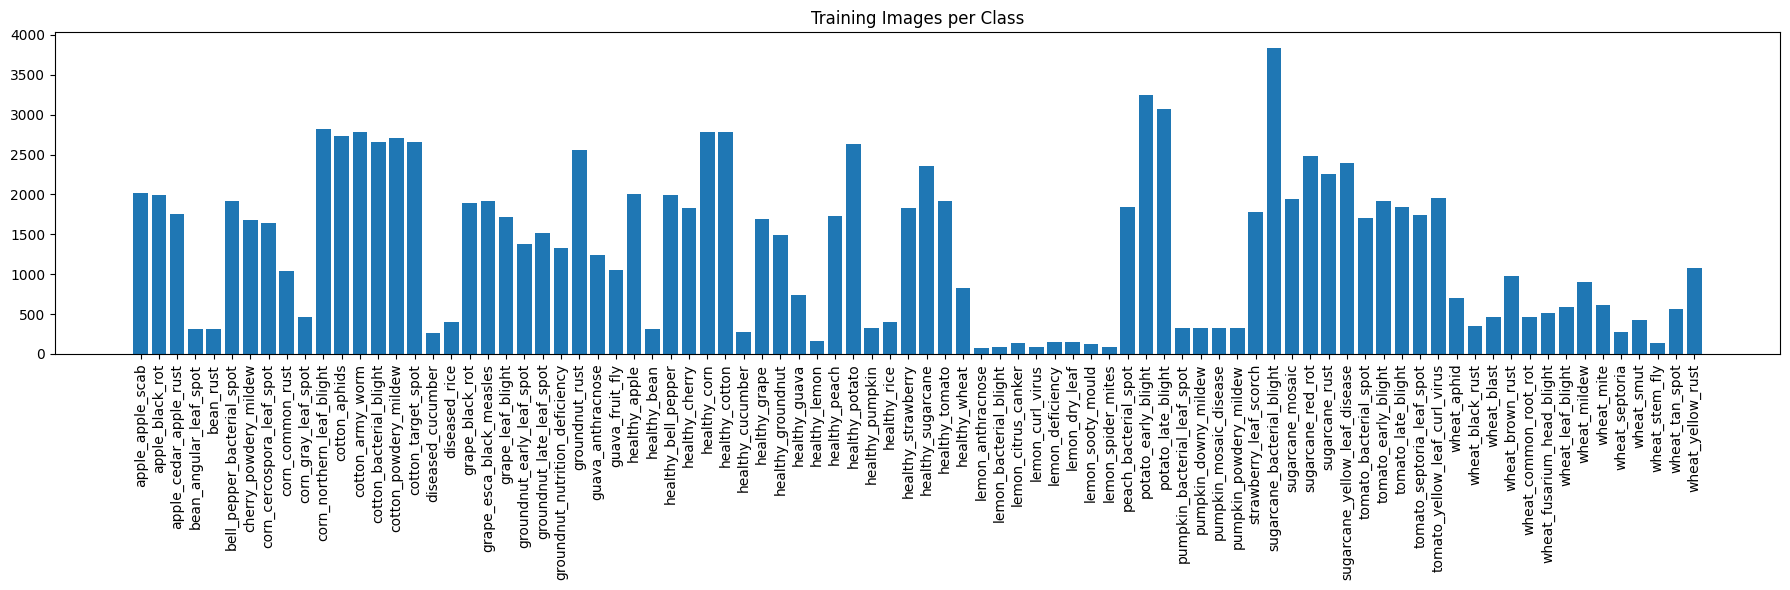

In [5]:
plt.figure(figsize=(18,6))

plt.bar(class_df["Class"], class_df["Images"])

plt.xticks(rotation=90)

plt.title("Training Images per Class")

plt.tight_layout()

plt.show()

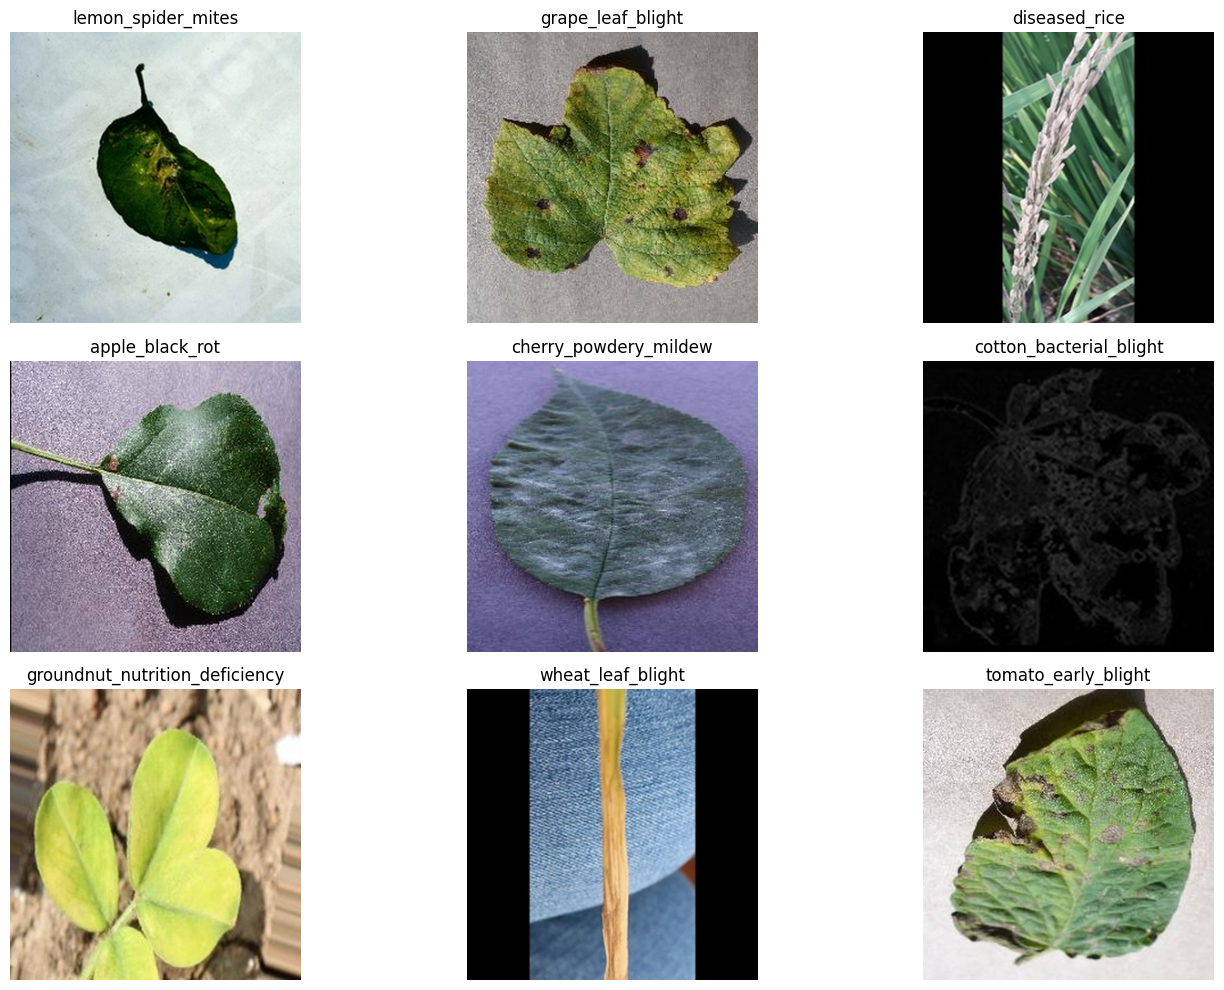

In [6]:
plt.figure(figsize=(15,10))

for i in range(9):

    cls = random.choice(classes)

    img_name = random.choice(
        os.listdir(os.path.join(TRAIN_DIR, cls))
    )

    img_path = os.path.join(TRAIN_DIR, cls, img_name)

    img = plt.imread(img_path)

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [7]:
# ============================================================
# 2. DATA LOADING & PREPROCESSING
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)
# Save class names here
class_names = train_ds.class_names
num_classes = len(class_names)

print(num_classes)
print(class_names[:10])

Found 115076 files belonging to 86 classes.


I0000 00:00:1783767111.407215      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783767111.410080      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 14356 files belonging to 86 classes.
Found 14454 files belonging to 86 classes.
86
['apple_apple_scab', 'apple_black_rot', 'apple_cedar_apple_rust', 'bean_angular_leaf_spot', 'bean_rust', 'bell_pepper_bacterial_spot', 'cherry_powdery_mildew', 'corn_cercospora_leaf_spot', 'corn_common_rust', 'corn_gray_leaf_spot']


In [9]:
# Improve data pipeline performance

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [10]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1),
], name="data_augmentation")

In [11]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os

class_names = sorted(os.listdir(TRAIN_DIR))

labels = []

for idx, class_name in enumerate(class_names):
    class_path = os.path.join(TRAIN_DIR, class_name)
    num_images = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
    labels.extend([idx] * num_images)

labels = np.array(labels)

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(weights))

print(class_weights)

{0: np.float64(0.6637366186784791), 1: np.float64(0.6734237661076065), 2: np.float64(0.7602801268498943), 3: np.float64(4.302549914005833), 4: np.float64(4.261442749222337), 5: np.float64(0.6998394473095261), 6: np.float64(0.7950641849410659), 7: np.float64(0.8154131768774003), 8: np.float64(1.281698298137753), 9: np.float64(2.9152353447839086), 10: np.float64(0.4739968201402104), 11: np.float64(0.4905033076450931), 12: np.float64(0.48029182457136177), 13: np.float64(0.5045599635202919), 14: np.float64(0.49339713246895794), 15: np.float64(0.503610471680773), 16: np.float64(5.126793192551012), 17: np.float64(3.3121114437025096), 18: np.float64(0.7087357114702404), 19: np.float64(0.696923449612403), 20: np.float64(0.7775090199045984), 21: np.float64(0.9668302191154725), 22: np.float64(0.8826471129655765), 23: np.float64(1.0045743417836441), 24: np.float64(0.5233058362361416), 25: np.float64(1.0834761321909425), 26: np.float64(1.2755891546766578), 27: np.float64(0.669046511627907), 28: np

In [12]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pretrained weights
base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
print(base_model.summary())

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

None


In [14]:
from tensorflow.keras import layers, Model

inputs = layers.Input(shape=(224, 224, 3))

# Data Augmentation
x = data_augmentation(inputs)

# EfficientNet preprocessing
x = tf.keras.applications.efficientnet.preprocess_input(x)

# Base Model
x = base_model(x, training=False)

# Classification Head
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dropout(0.3)(x)

x = layers.Dense(
    512,
    activation="relu",
    kernel_regularizer=tf.keras.regularizers.l2(0.001)
)(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = Model(inputs, outputs)

In [15]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 86)             │        44,118 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,754,681 (18.14 MB)

 Trainable params: 702,550 (2.68 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

callbacks = [
    early_stopping,
    reduce_lr,
    checkpoint
]

In [18]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/20


E0000 00:00:1783767139.550046      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


3597/3597 ━━━━━━━━━━━━━━━━━━━━ 312s 83ms/step - accuracy: 0.7134 - loss: 2.0368 - val_accuracy: 0.8279 - val_loss: 1.4238 - learning_rate: 0.0010
Epoch 2/20
3597/3597 ━━━━━━━━━━━━━━━━━━━━ 295s 82ms/step - accuracy: 0.7661 - loss: 1.7417 - val_accuracy: 0.8434 - val_loss: 1.3414 - learning_rate: 0.0010
Epoch 3/20
3597/3597 ━━━━━━━━━━━━━━━━━━━━ 297s 82ms/step - accuracy: 0.7703 - loss: 1.6921 - val_accuracy: 0.8415 - val_loss: 1.3206 - learning_rate: 0.0010
Epoch 4/20
3597/3597 ━━━━━━━━━━━━━━━━━━━━ 296s 82ms/step - accuracy: 0.7740 - loss: 1.6408 - val_accuracy: 0.8523 - val_loss: 1.2524 - learning_rate: 0.0010
Epoch 5/20
3597/3597 ━━━━━━━━━━━━━━━━━━━━ 296s 82ms/step - accuracy: 0.7745 - loss: 1.6402 - val_accuracy: 0.8467 - val_loss: 1.2671 - learning_rate: 0.0010
Epoch 6/20
3597/3597 ━━━━━━━━━━━━━━━━━━━━ 296s 82ms/step - accuracy: 0.7750 - loss: 1.5993 - val_accuracy: 0.8584 - val_loss: 1.2308 - learning_rate: 0.0010
Epoch 7/20
3597/3597 ━━━━━━━━━━━━━━━━━━━━ 294s 82ms/step - accuracy: 

In [19]:
# Evaluate on the test set
test_loss, test_acc = model.evaluate(test_ds)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

452/452 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.8963 - loss: 0.5982
Test Accuracy: 0.8963
Test Loss: 0.5982


In [20]:
model.save("efficientnetb0_stage1.keras")

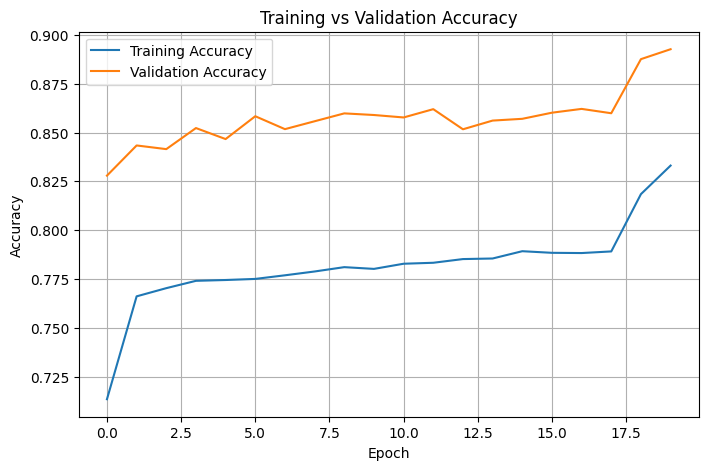

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

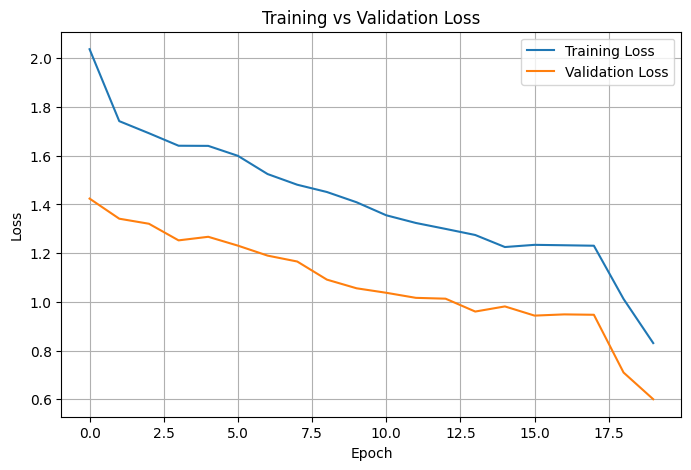

In [22]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [23]:
import numpy as np
from sklearn.metrics import classification_report

# True labels
y_true = np.concatenate([np.argmax(y, axis=1) for _, y in test_ds])

# Predicted labels
y_pred = np.argmax(model.predict(test_ds), axis=1)

# Classification Report
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

452/452 ━━━━━━━━━━━━━━━━━━━━ 35s 73ms/step
                                precision    recall  f1-score   support

              apple_apple_scab       0.97      0.92      0.95       252
               apple_black_rot       0.99      0.98      0.99       249
        apple_cedar_apple_rust       1.00      0.97      0.99       220
        bean_angular_leaf_spot       0.94      0.82      0.88        40
                     bean_rust       0.80      0.93      0.86        40
    bell_pepper_bacterial_spot       0.97      1.00      0.98       240
         cherry_powdery_mildew       1.00      1.00      1.00       211
     corn_cercospora_leaf_spot       0.92      0.73      0.81       206
              corn_common_rust       0.96      0.94      0.95       132
           corn_gray_leaf_spot       0.38      0.78      0.51        58
     corn_northern_leaf_blight       0.95      0.87      0.91       354
                 cotton_aphids       0.75      0.79      0.77       342
              cotton

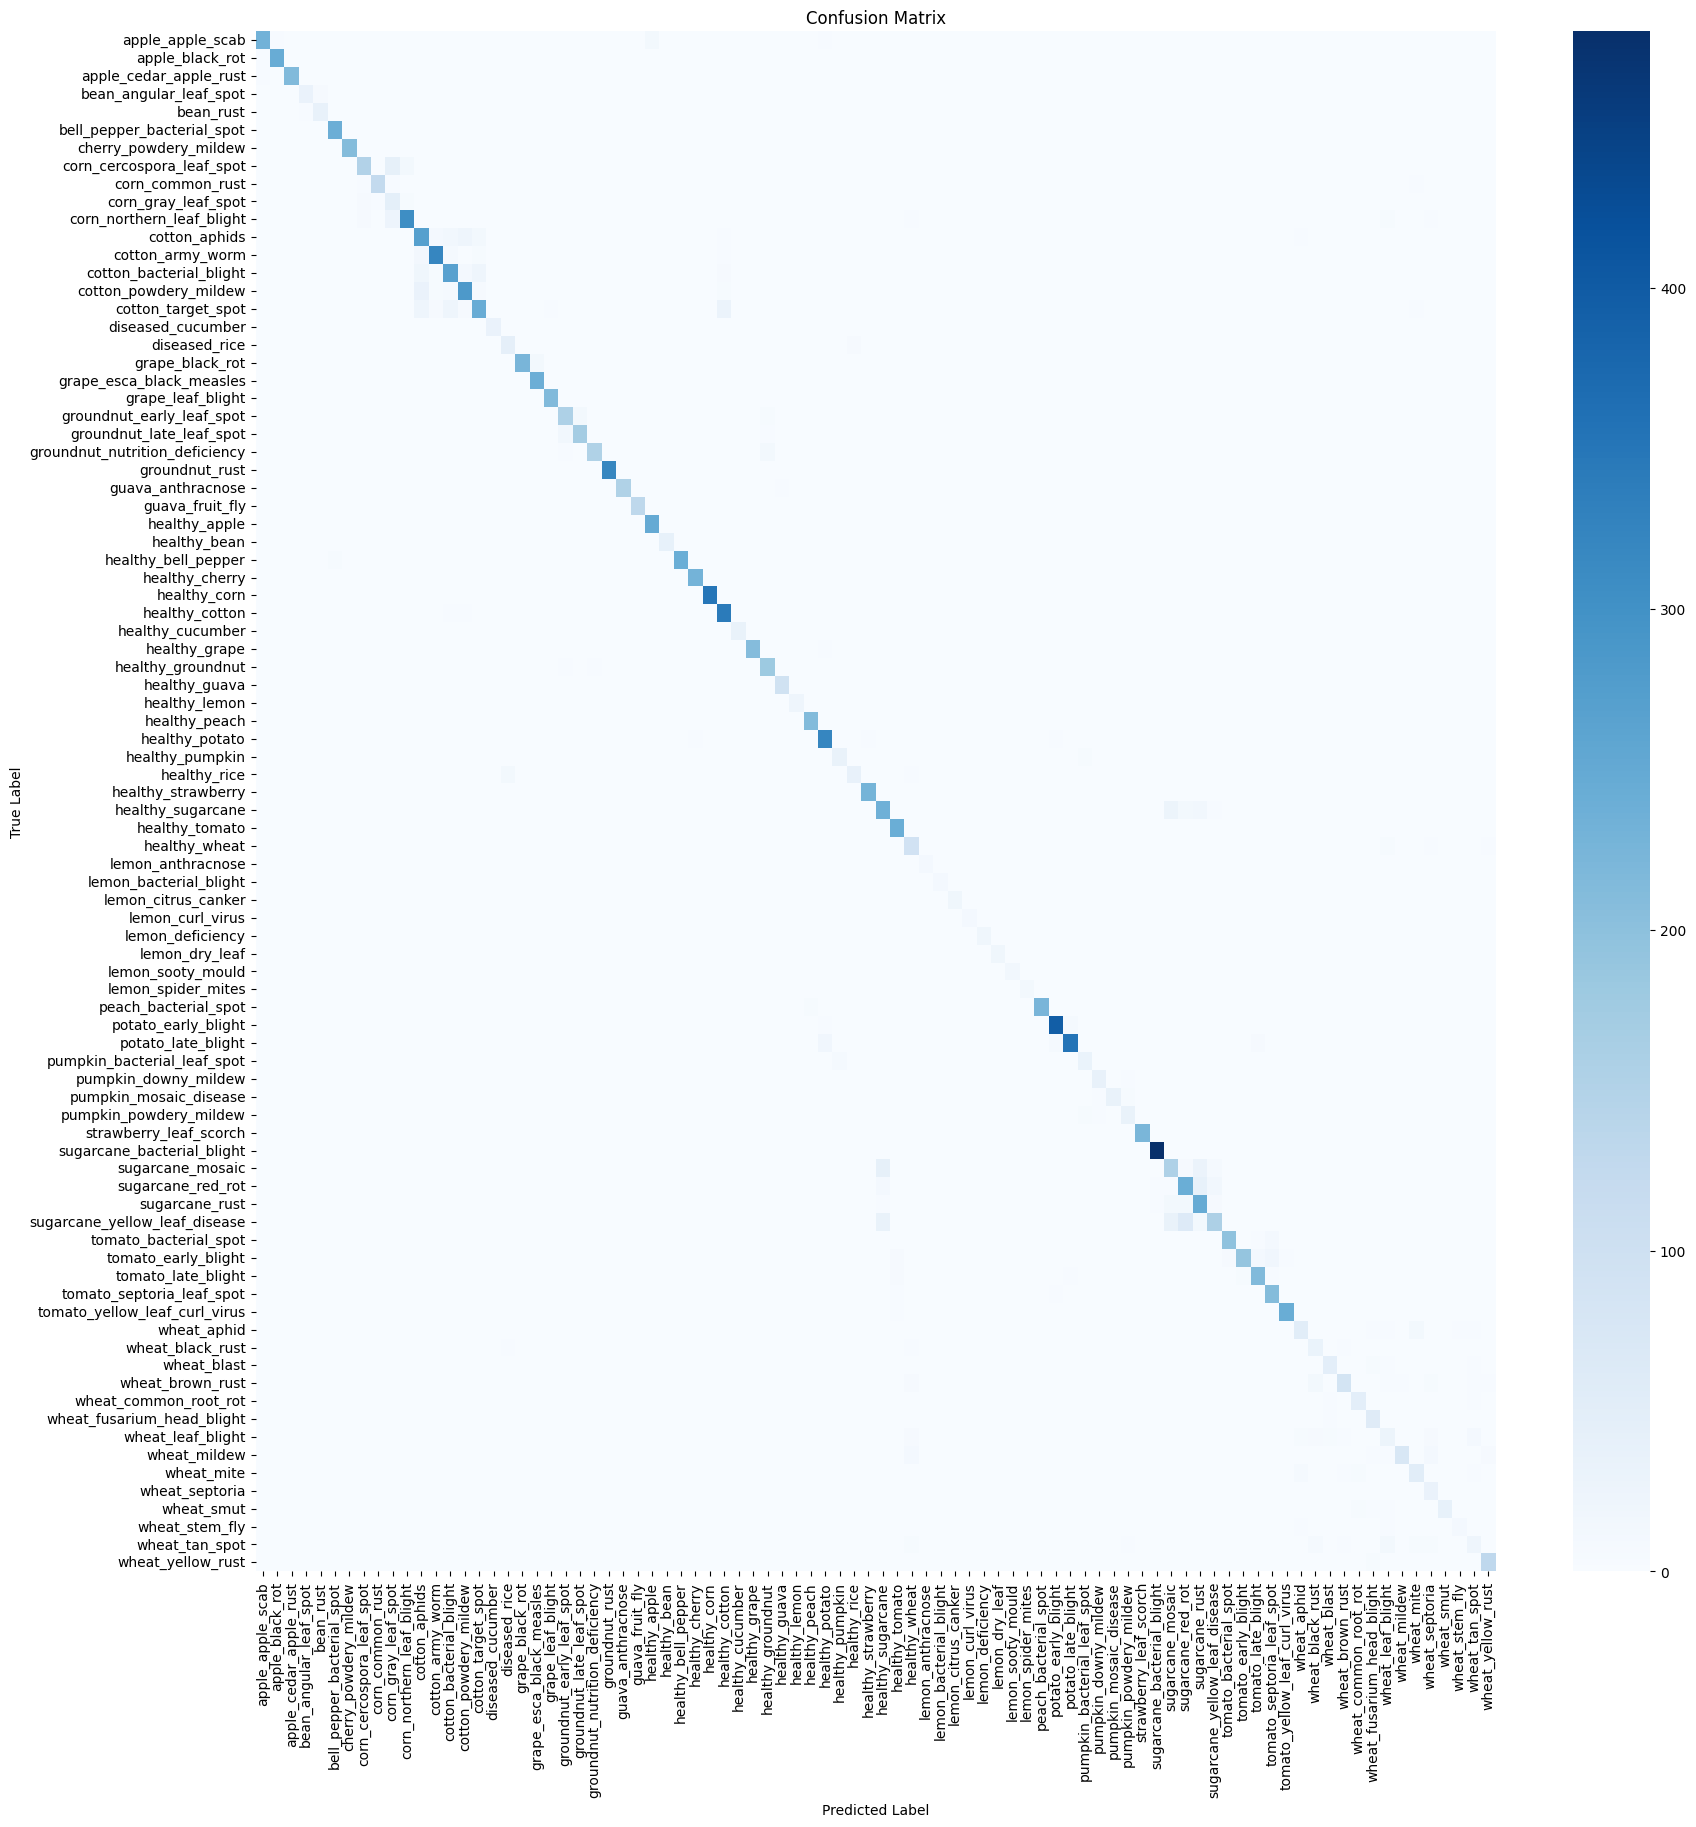

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 20))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [25]:
# Unfreeze the base model
base_model.trainable = True

In [26]:
for layer in base_model.layers[:-40]:
    layer.trainable = False

In [27]:
print("Trainable layers:", len([l for l in base_model.layers if l.trainable]))

Trainable layers: 40


In [28]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [29]:
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10


E0000 00:00:1783773277.328909      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


3597/3597 ━━━━━━━━━━━━━━━━━━━━ 378s 101ms/step - accuracy: 0.7980 - loss: 0.9275 - val_accuracy: 0.8904 - val_loss: 0.6143 - learning_rate: 1.0000e-05
Epoch 2/10
3597/3597 ━━━━━━━━━━━━━━━━━━━━ 359s 100ms/step - accuracy: 0.8370 - loss: 0.7801 - val_accuracy: 0.8988 - val_loss: 0.5760 - learning_rate: 1.0000e-05
Epoch 3/10
3597/3597 ━━━━━━━━━━━━━━━━━━━━ 360s 100ms/step - accuracy: 0.8514 - loss: 0.7265 - val_accuracy: 0.9058 - val_loss: 0.5510 - learning_rate: 1.0000e-05
Epoch 4/10
3597/3597 ━━━━━━━━━━━━━━━━━━━━ 360s 100ms/step - accuracy: 0.8604 - loss: 0.6963 - val_accuracy: 0.9097 - val_loss: 0.5304 - learning_rate: 1.0000e-05
Epoch 5/10
3597/3597 ━━━━━━━━━━━━━━━━━━━━ 360s 100ms/step - accuracy: 0.8695 - loss: 0.6627 - val_accuracy: 0.9140 - val_loss: 0.5127 - learning_rate: 1.0000e-05
Epoch 6/10
3597/3597 ━━━━━━━━━━━━━━━━━━━━ 360s 100ms/step - accuracy: 0.8754 - loss: 0.6364 - val_accuracy: 0.9178 - val_loss: 0.4976 - learning_rate: 1.0000e-05
Epoch 7/10
3597/3597 ━━━━━━━━━━━━━━━━━━

In [30]:
test_loss, test_acc = model.evaluate(test_ds)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

452/452 ━━━━━━━━━━━━━━━━━━━━ 31s 68ms/step - accuracy: 0.9289 - loss: 0.4461
Test Accuracy: 0.9289
Test Loss: 0.4461


In [31]:
model.save("plant_disease_efficientnetb0_final.keras")

In [32]:
import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

In [33]:
import numpy as np

# True labels
y_true = np.concatenate([np.argmax(labels.numpy(), axis=1) for _, labels in test_ds])

# Predicted labels
y_pred = np.argmax(model.predict(test_ds, verbose=1), axis=1)

452/452 ━━━━━━━━━━━━━━━━━━━━ 35s 73ms/step


In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm.shape)

(86, 86)


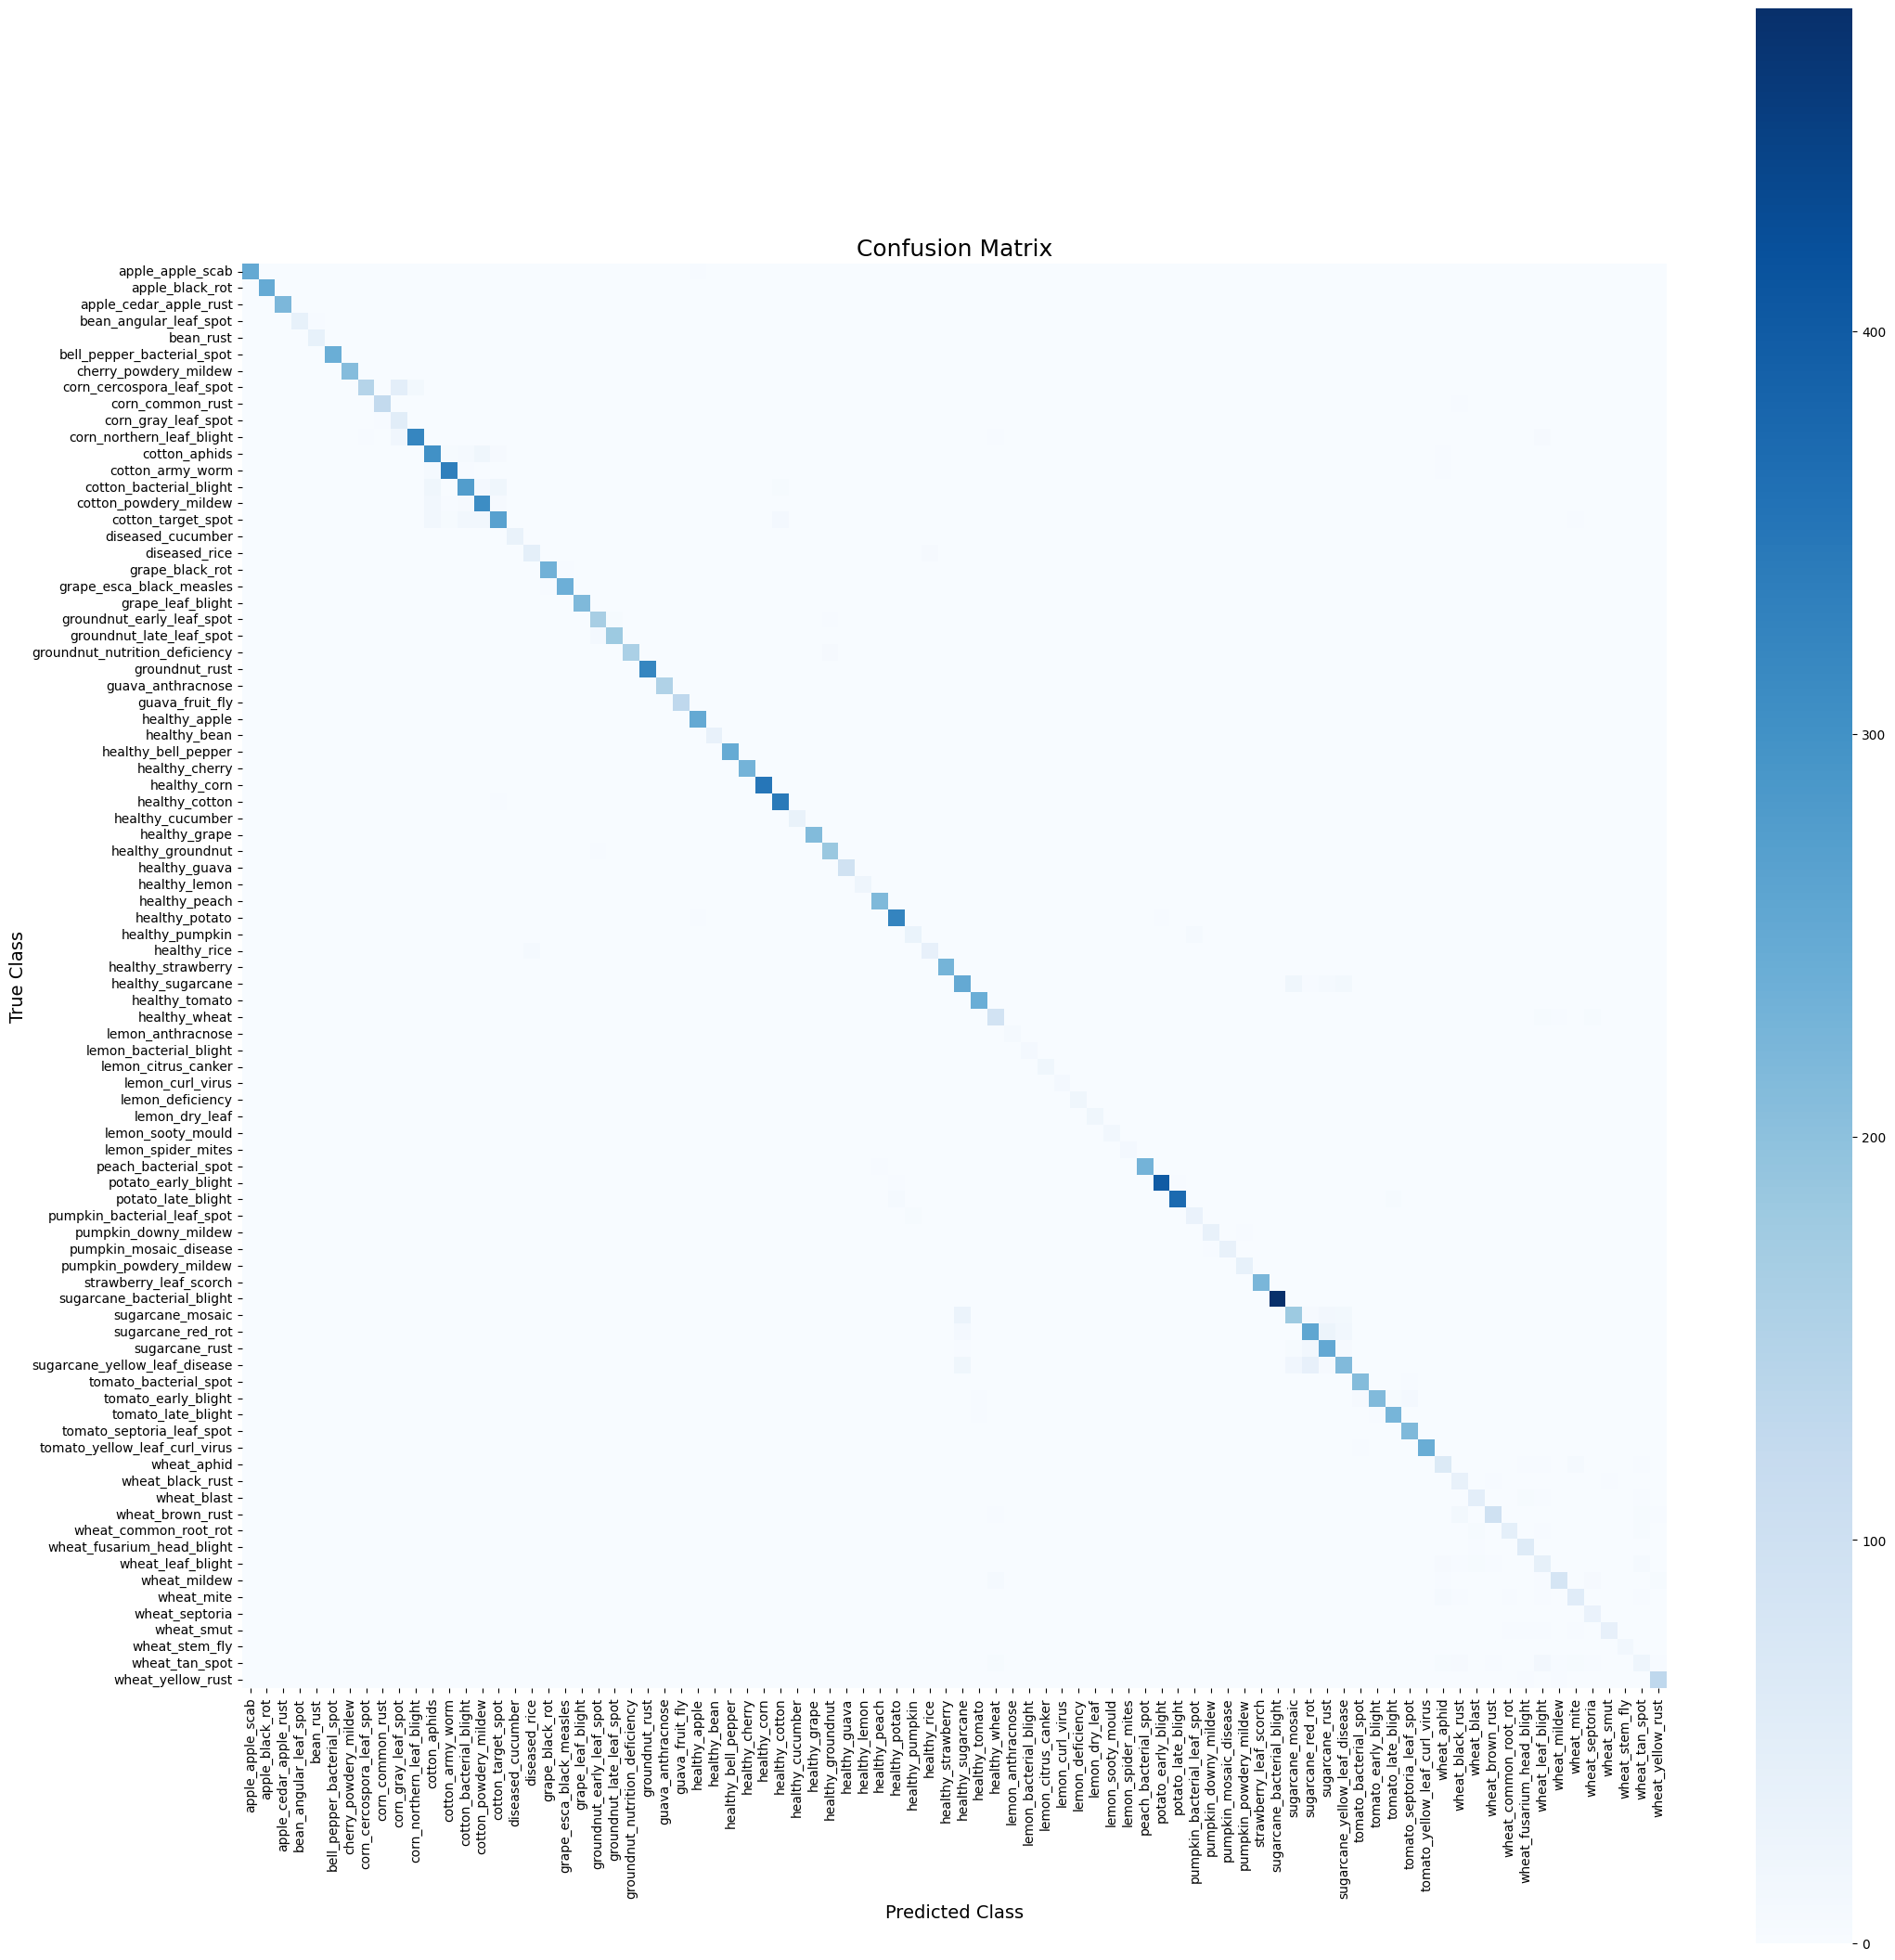

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(22,22))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    square=True,
    cbar=True
)

plt.title("Confusion Matrix", fontsize=18)
plt.xlabel("Predicted Class", fontsize=14)
plt.ylabel("True Class", fontsize=14)

plt.tight_layout()
plt.show()

In [36]:
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

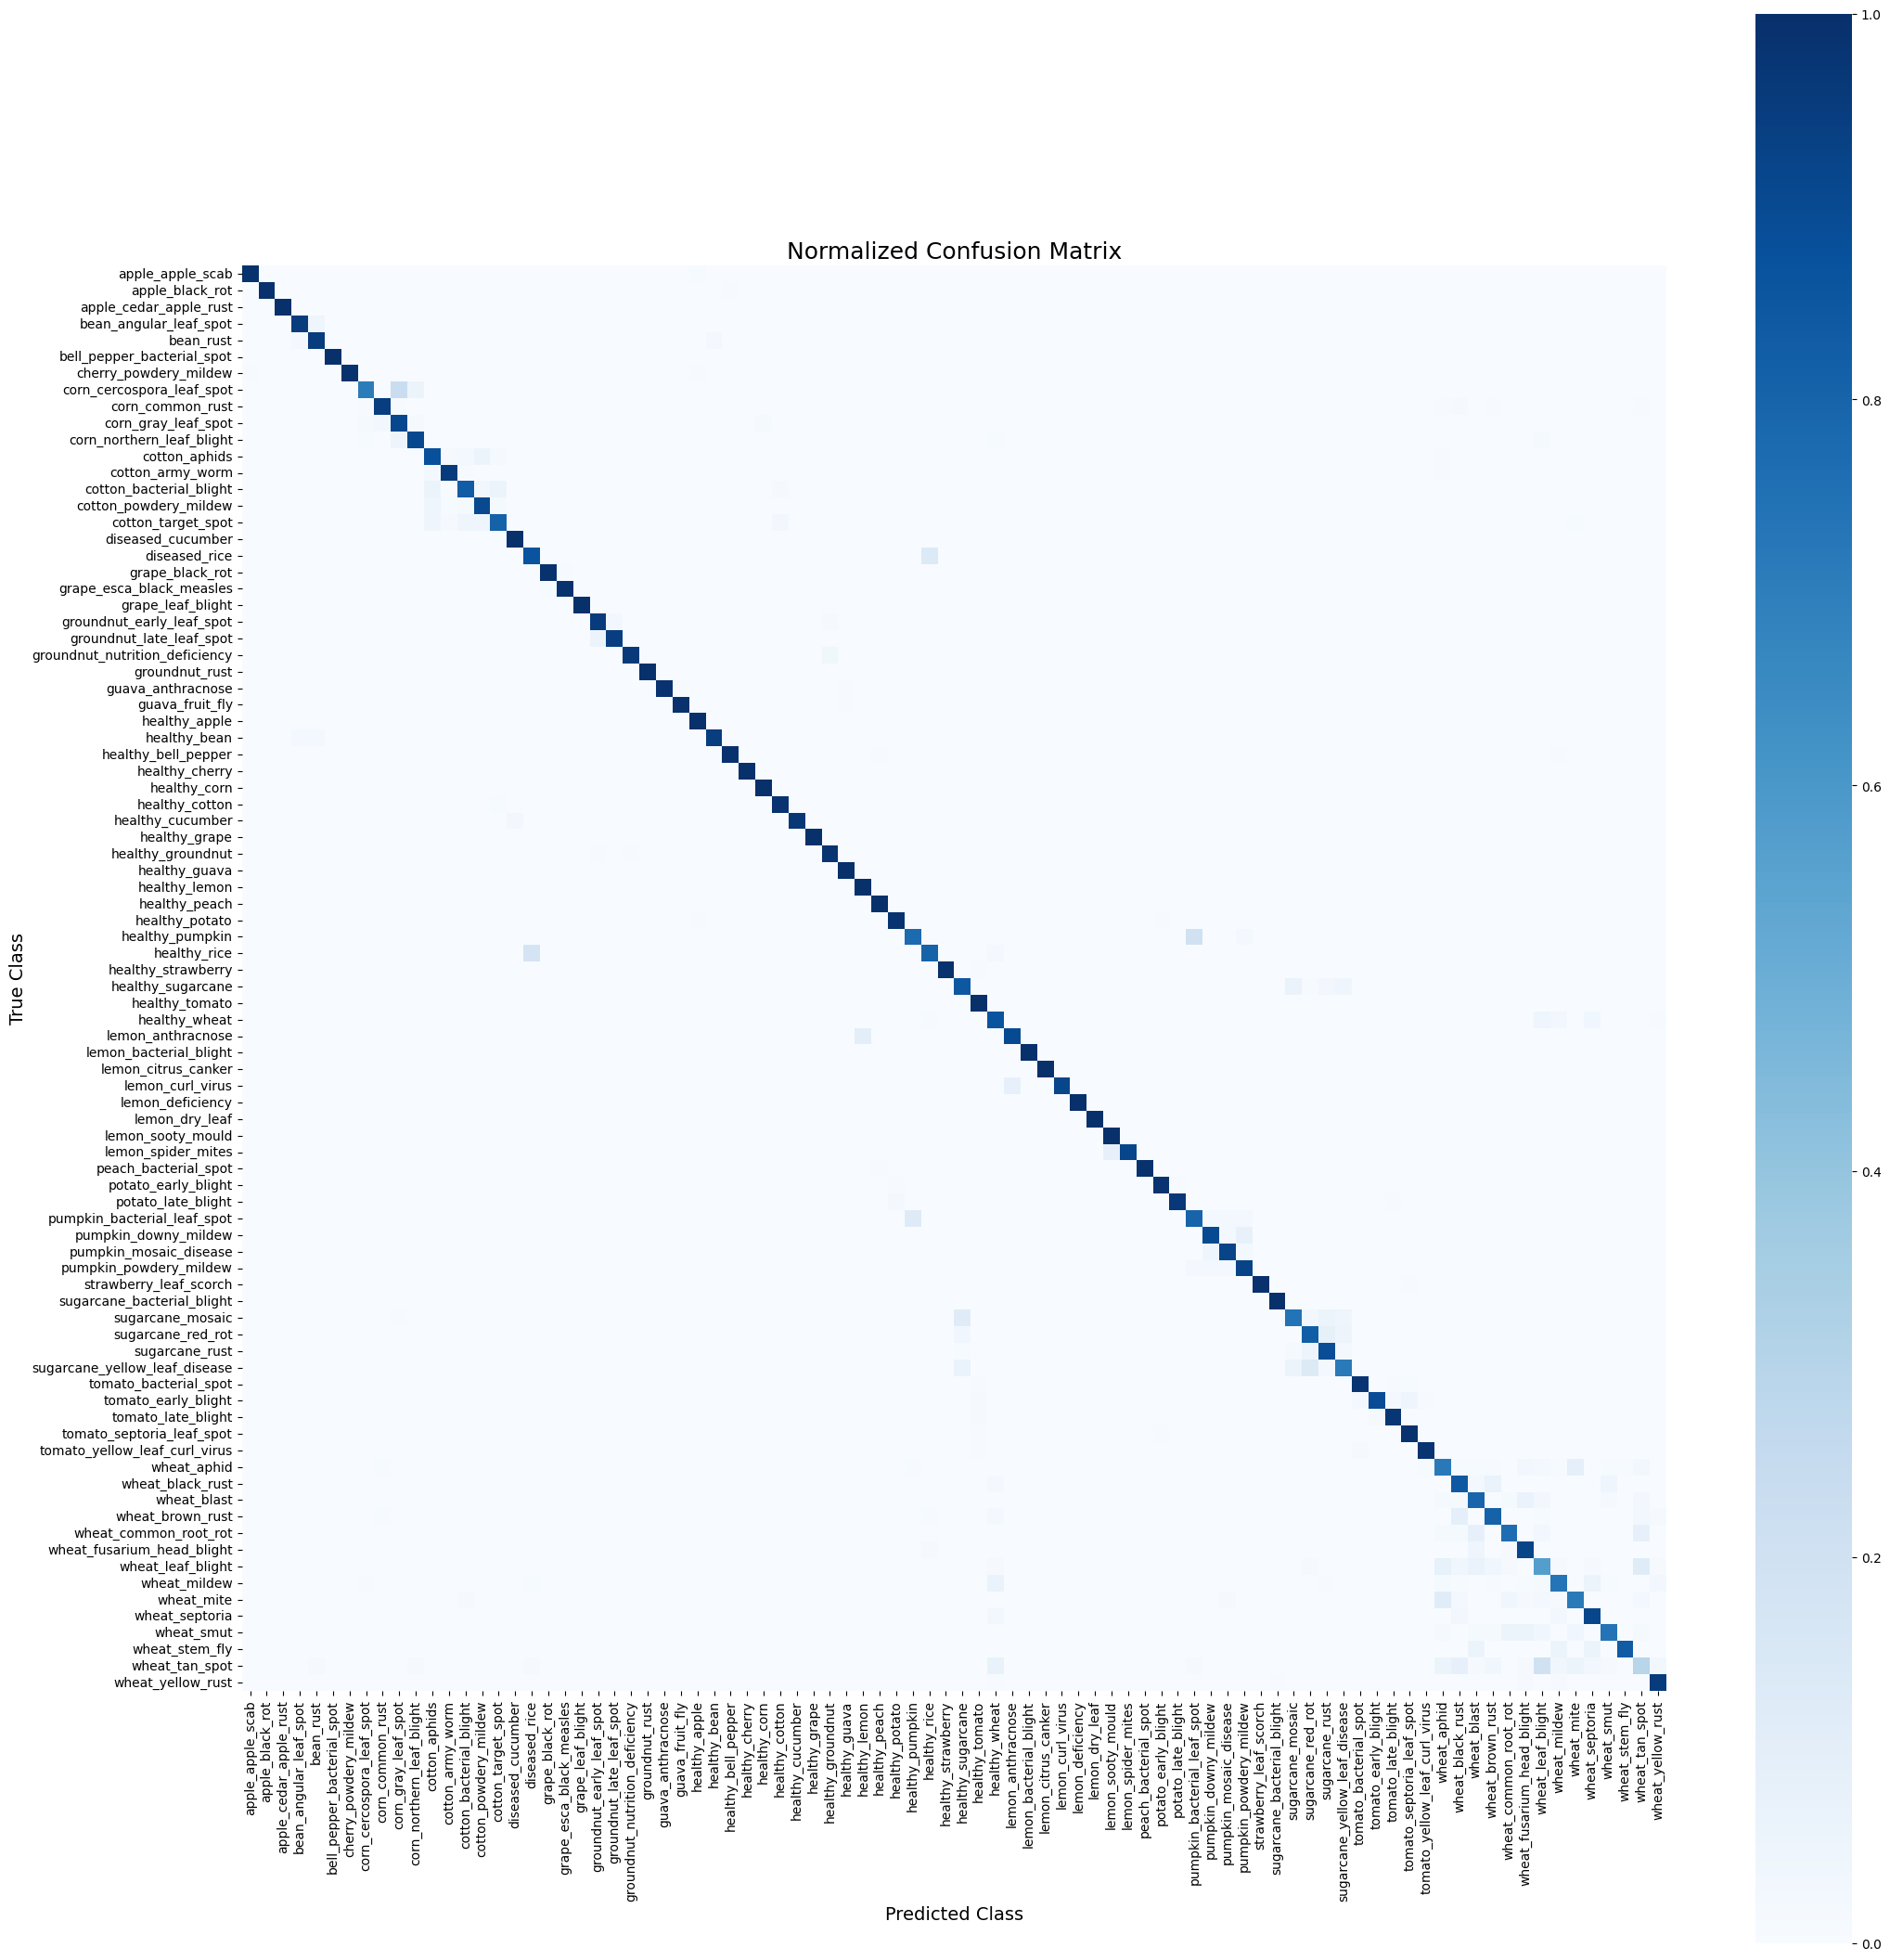

In [37]:
plt.figure(figsize=(22,22))

sns.heatmap(
    cm_normalized,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    square=True,
    cbar=True,
    vmin=0,
    vmax=1
)

plt.title("Normalized Confusion Matrix", fontsize=18)
plt.xlabel("Predicted Class", fontsize=14)
plt.ylabel("True Class", fontsize=14)

plt.tight_layout()
plt.show()

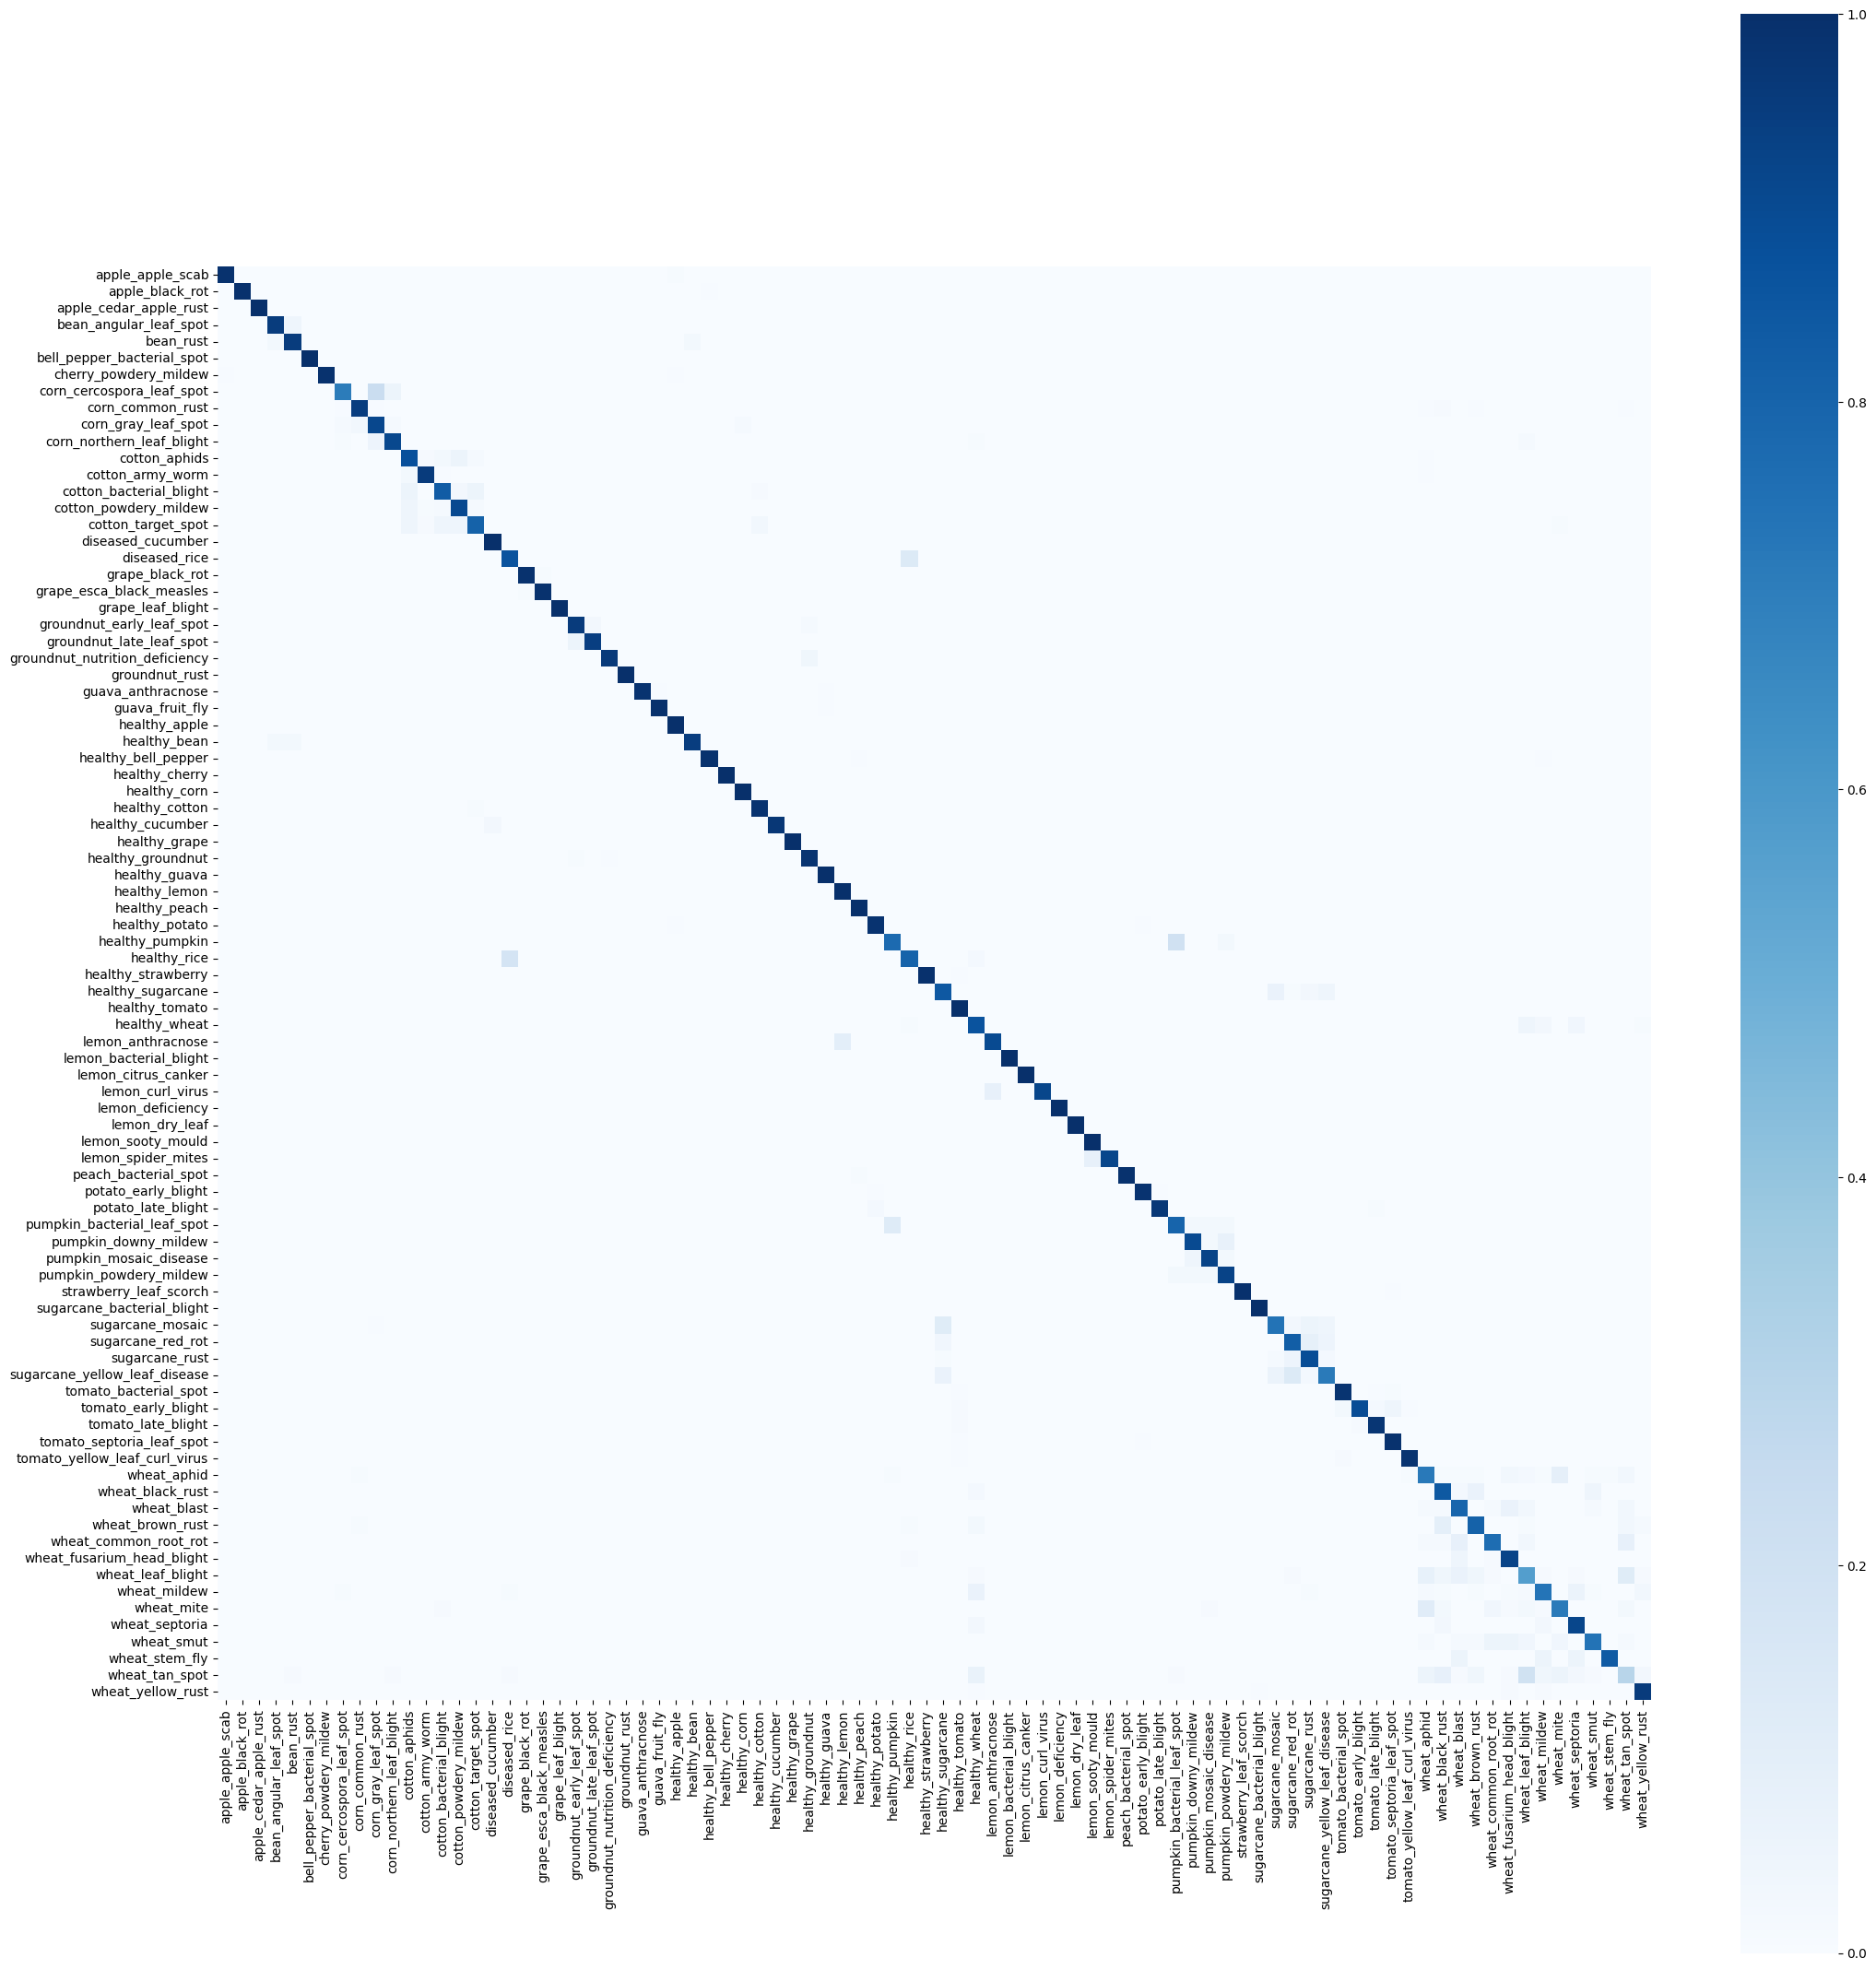

In [38]:
plt.figure(figsize=(22,22))

sns.heatmap(
    cm_normalized,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    square=True
)

plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

True Class: diseased_rice
Image: aef39d70-158e-5464-ac40-ed6d03aa44ca.jpg


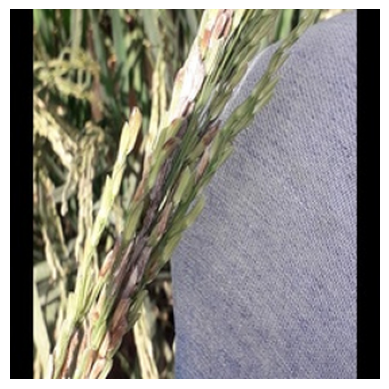

In [39]:
#predict on the test data
import random
import os
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Select a random class
random_class = random.choice(class_names)

# Path to that class in test set
class_path = os.path.join(TEST_DIR, random_class)

# Select a random image
img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

print("True Class:", random_class)
print("Image:", img_name)

# Display image
img = image.load_img(img_path)
plt.imshow(img)
plt.axis("off")
plt.show()

In [40]:
# Load and preprocess image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array, verbose=0)

pred_class = class_names[np.argmax(pred)]
confidence = np.max(pred) * 100

print(f"Predicted Class : {pred_class}")
print(f"Confidence      : {confidence:.2f}%")
print(f"Actual Class    : {random_class}")

Predicted Class : diseased_rice
Confidence      : 99.98%
Actual Class    : diseased_rice


In [41]:
top5 = np.argsort(pred[0])[-5:][::-1]

print("Top 5 Predictions:\n")

for i in top5:
    print(f"{class_names[i]:35s} {pred[0][i]*100:.2f}%")

Top 5 Predictions:

diseased_rice                       99.98%
wheat_fusarium_head_blight          0.01%
healthy_rice                        0.00%
wheat_smut                          0.00%
wheat_tan_spot                      0.00%
